In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q faster-whisper ffmpeg-python opencv-python-headless yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 50.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 45.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 66.2 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import json
import subprocess
import cv2
import torch
from faster_whisper import WhisperModel

In [3]:
VIDEO_URL_OR_PATH = "https://ok.ru/video/248244667877"   # <-- set this
TARGET_DIALOGUE   = "My mind rebels at stagnation"     # <-- set this
WORK_DIR          = "/kaggle/working"
VIDEO_PATH        = os.path.join(WORK_DIR, "input_video.mp4")
AUDIO_PATH        = os.path.join(WORK_DIR, "audio.wav")
FRAME_OUT_PATH    = os.path.join(WORK_DIR, "matched_frame.jpg")

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
# STAGE 1: VIDEO ACQUISITION
# =============================================================================
# %% [cell] 4. Acquire video (URL download or local copy)
def acquire_video(source: str, dest: str) -> str:
    """Download if source is a URL, else assume it's already a local path."""
    if source.startswith("http://") or source.startswith("https://"):
        # yt-dlp handles both direct file links and platform URLs (YouTube etc.)
        cmd = ["yt-dlp", "-f", "mp4", "-o", dest, source]
        subprocess.run(cmd, check=True)
    else:
        dest = source  # already local, e.g. a Kaggle-uploaded file
    return dest
 
VIDEO_PATH = acquire_video(VIDEO_URL_OR_PATH, VIDEO_PATH)
print(f"Video ready at: {VIDEO_PATH}")

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning


[Odnoklassniki] Extracting URL: https://ok.ru/video/248244667877
[Odnoklassniki] 248244667877: Downloading desktop webpage
[Odnoklassniki] 248244667877: Downloading m3u8 information
[info] 248244667877: Downloading 1 format(s): hls-2565
[hlsnative] Downloading m3u8 manifest
[hlsnative] Total fragments: 327
[download] Destination: /kaggle/working/input_video.mp4
[download] 100% of  997.69MiB in 00:01:54 at 8.75MiB/s                   
[FixupM3u8] Fixing MPEG-TS in MP4 container of "/kaggle/working/input_video.mp4"
Video ready at: /kaggle/working/input_video.mp4


In [6]:
 #STAGE 2: METADATA EXTRACTION (fps / duration)
# =============================================================================
# %% [cell] 5. Extract fps, frame count, duration, and check CFR vs VFR
def get_video_metadata(video_path: str) -> dict:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps else 0
    cap.release()
 
    # Cross-check with ffprobe (also flags variable frame rate)
    probe = subprocess.run(
        ["ffprobe", "-v", "error", "-select_streams", "v:0",
         "-show_entries", "stream=r_frame_rate,avg_frame_rate",
         "-of", "json", video_path],
        capture_output=True, text=True
    )
    probe_data = json.loads(probe.stdout)
    r_rate = probe_data["streams"][0]["r_frame_rate"]
    avg_rate = probe_data["streams"][0]["avg_frame_rate"]
    is_vfr = r_rate != avg_rate
 
    return {
        "fps": fps,
        "total_frames": total_frames,
        "duration_sec": duration,
        "is_vfr": is_vfr
    }
 
metadata = get_video_metadata(VIDEO_PATH)
print(metadata)
if metadata["is_vfr"]:
    print("WARNING: Variable frame rate detected. Frame math may be imprecise (known MVP limitation).")

{'fps': 23.97616608930767, 'total_frames': 78204, 'duration_sec': 3261.7391666666667, 'is_vfr': True}


In [7]:
# STAGE 3: AUDIO EXTRACTION
# =============================================================================
# %% [cell] 6. Extract mono 16kHz WAV audio (Whisper's expected input format)
def extract_audio(video_path: str, audio_path: str) -> str:
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-ar", "16000", "-ac", "1", "-vn", audio_path
    ]
    subprocess.run(cmd, check=True, capture_output=True)
    return audio_path
 
extract_audio(VIDEO_PATH, AUDIO_PATH)
print(f"Audio extracted to: {AUDIO_PATH}")

Audio extracted to: /kaggle/working/audio.wav


In [8]:

# STAGE 4: VAD + ASR (faster-whisper has built-in VAD filtering)
# =============================================================================
# %% [cell] 7. Transcribe with word-level timestamps
# faster-whisper runs efficiently on a single T4; large-v3 is fine here.
# vad_filter=True strips silence/music before transcription, reducing
# hallucination and wasted compute (this is our VAD stage).
def transcribe(audio_path: str, model_size: str = "large-v3"):
    model = WhisperModel(model_size, device=DEVICE, compute_type="float16")
    segments, info = model.transcribe(
        audio_path,
        word_timestamps=True,
        vad_filter=True,
        vad_parameters=dict(min_silence_duration_ms=500)
    )
    # segments is a generator; materialize it
    segments = list(segments)
    print(f"Detected language: {info.language} (p={info.language_probability:.2f})")
    return segments
 
segments = transcribe(AUDIO_PATH)
print(f"Transcribed {len(segments)} segments.")

Detected language: en (p=0.99)
Transcribed 528 segments.


In [9]:
# STAGE 5: DIALOGUE MATCHING (coarse: segment-level, fine: word-level)
# =============================================================================
# %% [cell] 8. Find the target dialogue and resolve a precise timestamp
def match_dialogue(segments, target_text: str):
    target_norm = target_text.strip().lower()
 
    for seg in segments:
        seg_text_norm = seg.text.strip().lower()
 
        # --- Coarse match: exact substring at segment level ---
        if target_norm in seg_text_norm:
            # --- Fine match: locate the specific word span within the segment ---
            words = seg.words  # list of Word(word, start, end, probability)
            target_words = target_norm.split()
 
            # find the first word of target_text within this segment's word list
            match_start_time = seg.start  # fallback: segment start
            for i in range(len(words)):
                window = " ".join(
                    w.word.strip().lower() for w in words[i:i + len(target_words)]
                )
                if window.startswith(target_words[0]) and target_norm in seg_text_norm:
                    match_start_time = words[i].start
                    break
 
            return {
                "matched_segment_text": seg.text.strip(),
                "segment_start": seg.start,
                "segment_end": seg.end,
                "target_timestamp": match_start_time
            }
 
    return None  # not found (out of scope for MVP -- assumed always present)
 
match = match_dialogue(segments, TARGET_DIALOGUE)
if match is None:
    raise ValueError("Dialogue not found in transcript.")
print(match)

{'matched_segment_text': 'My mind rebels at stagnation.', 'segment_start': np.float64(324.68), 'segment_end': np.float64(327.72), 'target_timestamp': np.float64(324.68)}


In [10]:
# STAGE 6 + 7: FRAME LOCALIZATION + EXTRACTION
# =============================================================================
# %% [cell] 9. Convert timestamp -> frame number, then extract the frame
def extract_frame(video_path: str, timestamp_sec: float, fps: float, out_path: str):
    frame_number = round(timestamp_sec * fps)
 
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, frame = cap.read()
    cap.release()
 
    if not success:
        raise RuntimeError(f"Could not read frame {frame_number}")
 
    cv2.imwrite(out_path, frame)
    return frame_number
 
frame_number = extract_frame(
    VIDEO_PATH, match["target_timestamp"], metadata["fps"], FRAME_OUT_PATH
)

{
  "query": "My mind rebels at stagnation",
  "matched_text": "My mind rebels at stagnation.",
  "timestamp_sec": 324.68,
  "frame_number": 7785,
  "frame_image_path": "/kaggle/working/matched_frame.jpg"
}


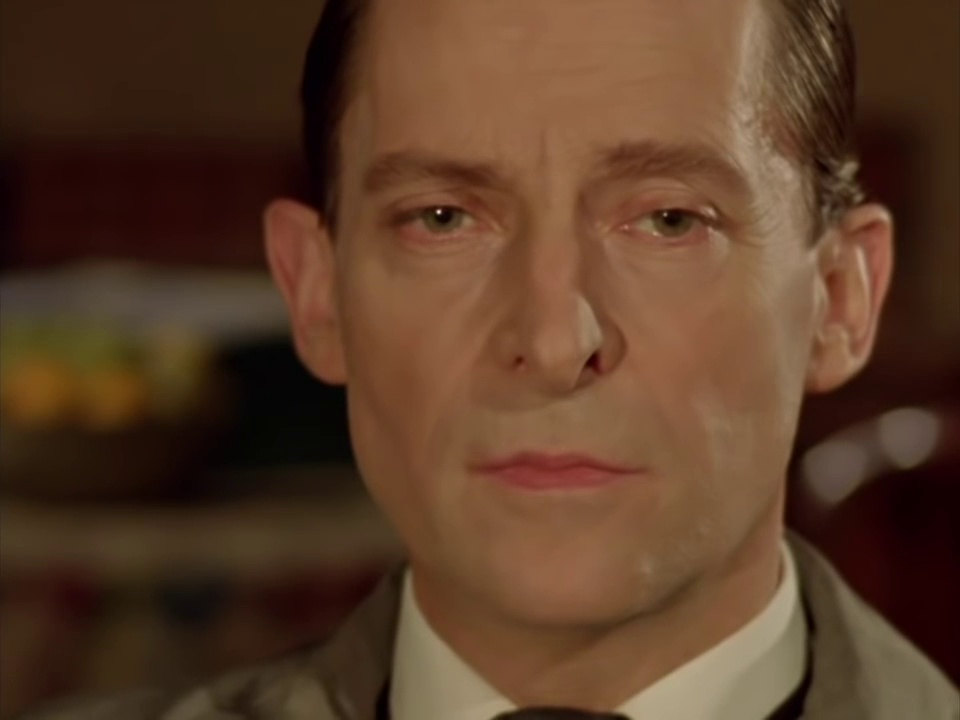

In [11]:
# STAGE 8: OUTPUT ASSEMBLY
# =============================================================================
# %% [cell] 10. Final result object
result = {
    "query": TARGET_DIALOGUE,
    "matched_text": match["matched_segment_text"],
    "timestamp_sec": match["target_timestamp"],
    "frame_number": frame_number,
    "frame_image_path": FRAME_OUT_PATH
}
 
print(json.dumps(result, indent=2))
 
# %% [cell] 11. Display the extracted frame inline
from IPython.display import Image, display
display(Image(filename=FRAME_OUT_PATH))